In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix


In [24]:
df = pd.read_csv('f1_dataset.csv')

In [25]:
df = df.drop_duplicates()
needed_cols = ['time', 'laps', 'year', 'team', 'grand_prix', 'continent']
df = df.dropna(subset=needed_cols).copy()

df['laps'] = pd.to_numeric(df['laps'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['laps','year']).copy()



In [4]:
# 2.4 Convert time (string "HH:MM:SS" or variants) to seconds
def time_to_seconds(t):
    try:
        # remove whitespace & non-ascii if any
        t = str(t).strip()
        parts = t.split(':')
        # handle mm:ss or hh:mm:ss
        parts = [float(p) for p in parts]
        if len(parts) == 3:
            h, m, s = parts
        elif len(parts) == 2:
            h = 0.0
            m, s = parts
        else:
            return np.nan
        return int(h*3600 + m*60 + s)
    except Exception:
        return np.nan


In [5]:
df['time_seconds'] = df['time'].apply(time_to_seconds)
df = df.dropna(subset=['time_seconds']).copy()
df['time_seconds'] = df['time_seconds'].astype(int)

print("After time conversion:", df.shape[0])

After time conversion: 1142


In [6]:
le_gp = LabelEncoder()
le_cont = LabelEncoder()
le_team = LabelEncoder()

In [7]:
df['gp_encoded'] = le_gp.fit_transform(df['grand_prix'].astype(str))
df['continent_encoded'] = le_cont.fit_transform(df['continent'].astype(str))
df['team_encoded'] = le_team.fit_transform(df['team'].astype(str))

In [8]:
print(df[['laps','year','time','gp_encoded','continent_encoded','team']].head())

    laps  year      time  gp_encoded  continent_encoded  \
0   70.0  1950  02:13:23          11                  2   
1  100.0  1950  03:13:18          18                  2   
2  138.0  1950  02:46:55          35                  3   
3   42.0  1950  02:02:53          33                  2   
4   35.0  1950  02:47:26           5                  2   

                       team  
0                Alfa Romeo  
1                Alfa Romeo  
2  Kurtis Kraft Offenhauser  
3                Alfa Romeo  
4                Alfa Romeo  


Text(0.5, 0, 'Laps')

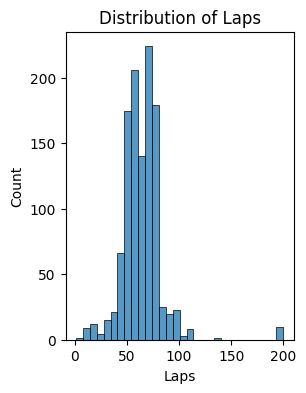

In [9]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
# 1) Distribution of laps
sns.histplot(df['laps'], bins=30, kde=False)
plt.title('Distribution of Laps')
plt.xlabel('Laps')

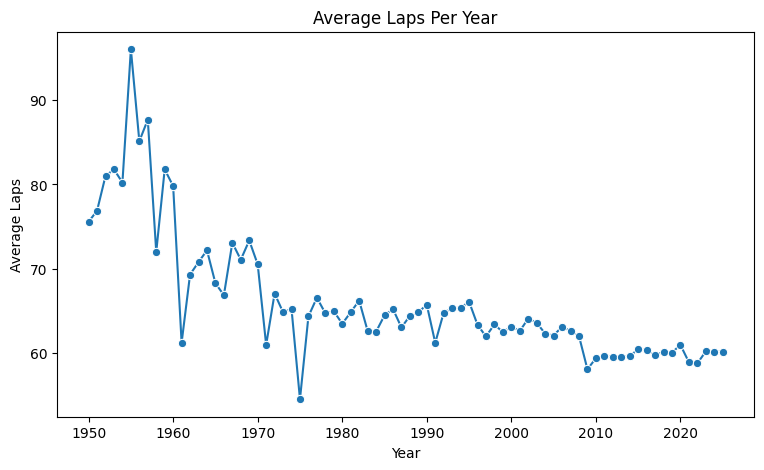

In [10]:
plt.figure(figsize=(9,5))

laps_year = df.groupby("year")["laps"].mean().reset_index()

sns.lineplot(data=laps_year, x="year", y="laps", marker='o')

plt.title("Average Laps Per Year")
plt.xlabel("Year")
plt.ylabel("Average Laps")
plt.show()



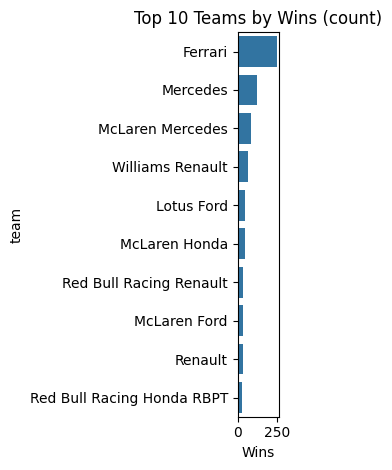

In [11]:
plt.subplot(1,3,3)
top_teams = df['team'].value_counts().nlargest(10)
sns.barplot(y=top_teams.index, x=top_teams.values)
plt.title('Top 10 Teams by Wins (count)')
plt.xlabel('Wins')
plt.tight_layout()
plt.show()

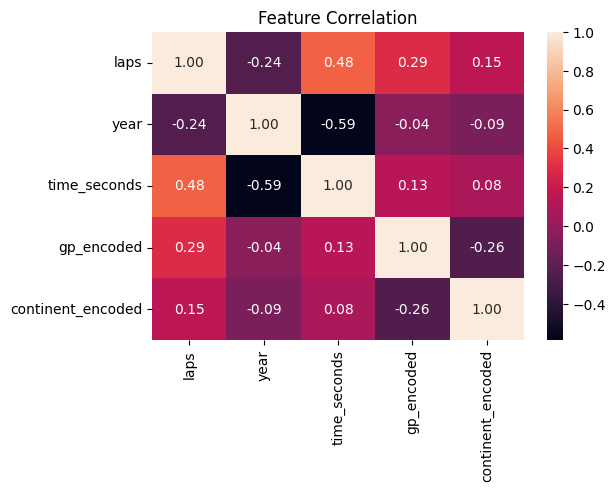

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['laps','year','time_seconds','gp_encoded','continent_encoded']].corr(), annot=True, fmt=".2f")
plt.title('Feature Correlation')
plt.show()

In [13]:
X_reg = df[['laps','year','gp_encoded','continent_encoded']].copy()
y_reg = df['time_seconds'].copy()

In [14]:
X_clf = df[['laps','year','time_seconds','gp_encoded','continent_encoded']].copy()
y_clf = df['team_encoded'].copy()

In [ ]:
scaler = StandardScaler()


In [16]:
# 4.1 Train-test split (use same random_state for reproducibility)
RANDOM_STATE = 42
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE)

print("Regression train/test shapes:", Xr_train.shape, Xr_test.shape)
print("Classification train/test shapes:", Xc_train.shape, Xc_test.shape)

Regression train/test shapes: (913, 4) (229, 4)
Classification train/test shapes: (913, 5) (229, 5)


In [17]:
# ---------------------------
# 5) Random Forest - Regression
# ---------------------------
rf_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(Xr_train, yr_train)
yr_pred = rf_reg.predict(Xr_test)

mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("\n--- RandomForestRegressor Results ---")
print("MSE:", round(mse,2))
print("RMSE:", round(rmse,2))
print("R2 score:", round(r2,4))


--- RandomForestRegressor Results ---
MSE: 635852.56
RMSE: 797.4
R2 score: 0.7814



Regression feature importances:
year                 0.733775
laps                 0.186169
gp_encoded           0.059748
continent_encoded    0.020309
dtype: float64


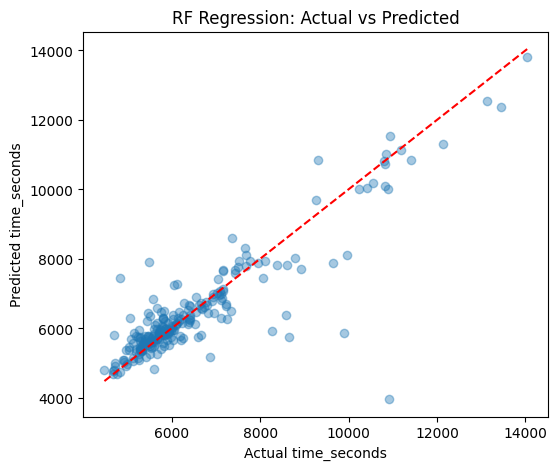

In [18]:
# Feature importances (regression)
fi_reg = pd.Series(rf_reg.feature_importances_, index=Xr_train.columns).sort_values(ascending=False)
print("\nRegression feature importances:")
print(fi_reg)

# Plot predicted vs actual (regression)
plt.figure(figsize=(6,5))
plt.scatter(yr_test, yr_pred, alpha=0.4)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
plt.xlabel('Actual time_seconds')
plt.ylabel('Predicted time_seconds')
plt.title('RF Regression: Actual vs Predicted')
plt.show()

In [19]:
# ---------------------------
# 6) Random Forest - Classification (FIXED)
# ---------------------------

rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(Xc_train, yc_train)
yc_pred = rf_clf.predict(Xc_test)

acc = accuracy_score(yc_test, yc_pred)

print("\n--- RandomForestClassifier Results ---")
print("Accuracy:", round(acc,4))

# FIX: dynamic label handling
labels = np.unique(np.concatenate((yc_test, yc_pred)))

team_names = le_team.inverse_transform(labels)

print("\nClassification report:")
print(classification_report(yc_test, yc_pred, labels=labels, target_names=team_names))



--- RandomForestClassifier Results ---
Accuracy: 0.4148

Classification report:
                            precision    recall  f1-score   support

                Alfa Romeo       1.00      1.00      1.00         2
                       BRM       0.00      0.00      0.00         3
             Benetton Ford       0.00      0.00      0.00         3
          Benetton Renault       0.00      0.00      0.00         5
               Brabham BMW       0.00      0.00      0.00         5
              Brabham Ford       0.00      0.00      0.00         2
             Brabham Repco       0.00      0.00      0.00         0
            Brawn Mercedes       0.00      0.00      0.00         1
             Cooper Climax       0.43      1.00      0.60         3
             Eagle Weslake       0.00      0.00      0.00         1
       Epperly Offenhauser       1.00      1.00      1.00         1
                   Ferrari       0.32      0.42      0.37        45
              Hesketh Ford       0

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{

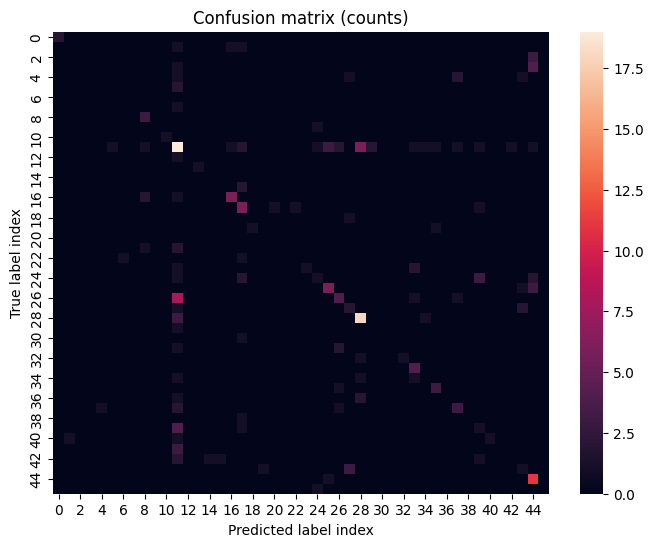

In [20]:
cm = confusion_matrix(yc_test, yc_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, fmt='d')
plt.title('Confusion matrix (counts)')
plt.xlabel('Predicted label index')
plt.ylabel('True label index')
plt.show()

In [21]:
# Feature importances (classification)
fi_clf = pd.Series(rf_clf.feature_importances_, index=Xc_train.columns).sort_values(ascending=False)
print("\nClassification feature importances:")
print(fi_clf)


Classification feature importances:
year                 0.446900
time_seconds         0.261725
laps                 0.135955
gp_encoded           0.114605
continent_encoded    0.040815
dtype: float64


In [22]:
# Summary prints for quick view
print("\nSUMMARY:")
print(f"RF Regression -> RMSE: {rmse:.2f}, R2: {r2:.4f}")
print(f"RF Classification -> Accuracy: {acc:.4f} (on test set of size {len(yc_test)})")


SUMMARY:
RF Regression -> RMSE: 797.40, R2: 0.7814
RF Classification -> Accuracy: 0.4148 (on test set of size 229)
